# Tutorial 7: Operations with peaks

The peak list can be modified using the [mlgidGUI](https://github.com/mlgid-project/mlgidGUI). This interactive interface allows users to visualize, adjust, and save peak selections directly to a `NeXus` file.

In addition, `mlgidBASE` provides basic functionality to delete and add peaks. First, run the analysis:

In [1]:
from mlgidbase import mlgidBASE
filename = '../../example/BA2PbI4.h5'
analysis = mlgidBASE(filename=filename)
analysis.run_detection()
analysis.run_fitting()
analysis.run_matching(
    cif_prepr = r'../../example/prepr_cifs.pickle',
    peaks_type='segments')

analysis.run_matching(
    cif_prepr = r'../../example/prepr_cifs.pickle',
    peaks_type='rings')

INFO - Loading model
INFO - Using the GPU for inference
INFO - Saved detected peaks to file: ../../example/BA2PbI4.h5, entry: entry_0000, frame: 0
INFO - Saved fitted peaks to file: ../../example/BA2PbI4.h5, entry: entry_0000, frame: 0
INFO - Saved matched peaks to file: ../../example/BA2PbI4.h5, entry: entry_0000, frame: 0
INFO - cif_prepr is already set. The previous cif_prepr is to be used
INFO - Saved matched peaks to file: ../../example/BA2PbI4.h5, entry: entry_0000, frame: 0


### Segments

Visualize the matched peaks

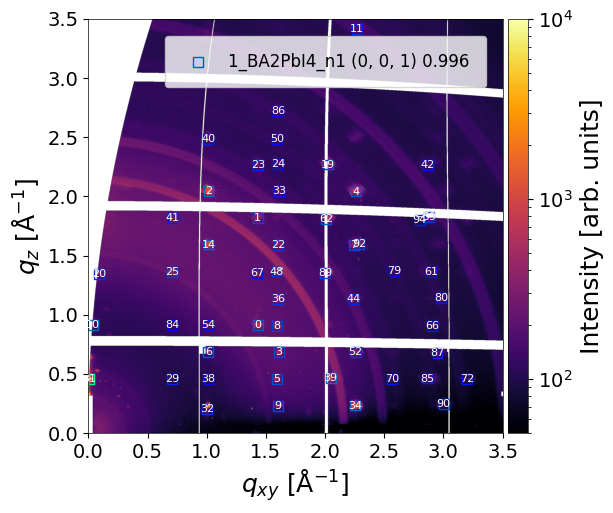

In [2]:
# Visualization settings for matched peaks (multiple structures in solution)
matched_params = {
    'solution': None,              # list of structures to display (None = all)
    'plot_segments': True,         # show matched peak positions
    'marker': ['s', 's', 's'],     # marker shapes for each structure
    'marker_size': [50, 50, 50],   # marker sizes for each structure
    'marker_facecolor': ["none", "none", "none"],  # marker fill colors
    'marker_edgecolor': ["winter", 'blue', 'green'], # marker edge colors per structure
    'plot_rings': False,            # draw matched rings
    'line_width': [1, 1, 1],       # line widths for each structure
    'line_style': ["--", "--", "--"], # line styles for each structure
    'line_color': ["bone", 'blue', 'bone'], # line colors per structure
    'plot_id': True,              # display peak IDs
    'text_color': 'white',         # color of ID labels
    'text_size': 8,                # font size of ID labels
    'legend': True,                # show legend for multiple structures
    'plot': True,                 # enable/disable plotting of matched peaks
}

# Plot analysis results with selected matched peak visualization
analysis.plot_analysis_results(
    matched_params=matched_params,
    entry='entry_0000',  # select entry
    frame_num=0,          # select frame
    clims=(50, 1e4),     # color map
)

Delete the peak #94

In [3]:
analysis.delete_peak(
    entry='entry_0000',
    frame_num=0,
    peak_id=94 # peak number
)

The peak dissapears from all: detected, fitted and matched (all solutions and structures) peak lists.

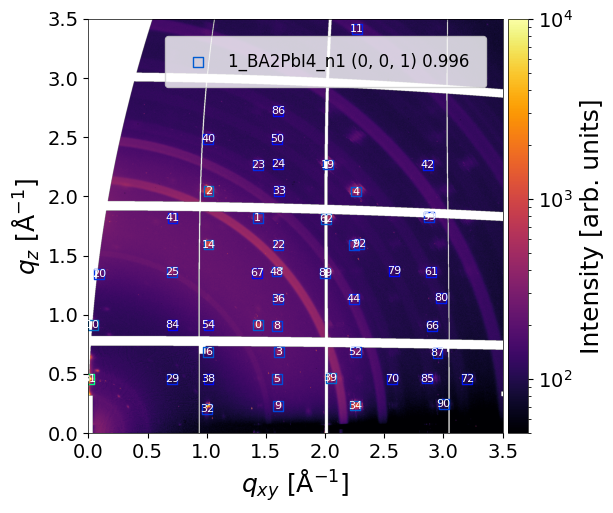

In [4]:
analysis.plot_analysis_results(
    matched_params=matched_params,
    entry='entry_0000',  # select entry
    frame_num=0,          # select frame
    clims=(50, 1e4),     # color map
)

Add a box for the missing peak at q_xy = 2.25, q_z=2.5.
NOTE: it appears only in detected peaks

In [5]:
analysis.add_peak(
    entry='entry_0000',
    frame_num=0,
    q_xy = 2.25, # box center in horizontal direction (Å⁻¹)
    dq_xy=0.1,   # box wight in horizontal direction (Å⁻¹)
    q_z=2.5,     # box center in vertical direction (Å⁻¹)
    dq_z=0.06    # box wight in vertical direction (Å⁻¹)
)

INFO - Peak id#94 has been added


Run fitting and matching:

In [6]:
analysis.run_fitting()
analysis.run_matching(
    cif_prepr = r'../../example/prepr_cifs.pickle',
    peaks_type='segments')

analysis.run_matching(
    cif_prepr = r'../../example/prepr_cifs.pickle',
    peaks_type='rings')

INFO - Saved fitted peaks to file: ../../example/BA2PbI4.h5, entry: entry_0000, frame: 0
INFO - cif_prepr is already set. The previous cif_prepr is to be used
INFO - Saved matched peaks to file: ../../example/BA2PbI4.h5, entry: entry_0000, frame: 0
INFO - cif_prepr is already set. The previous cif_prepr is to be used
INFO - Saved matched peaks to file: ../../example/BA2PbI4.h5, entry: entry_0000, frame: 0


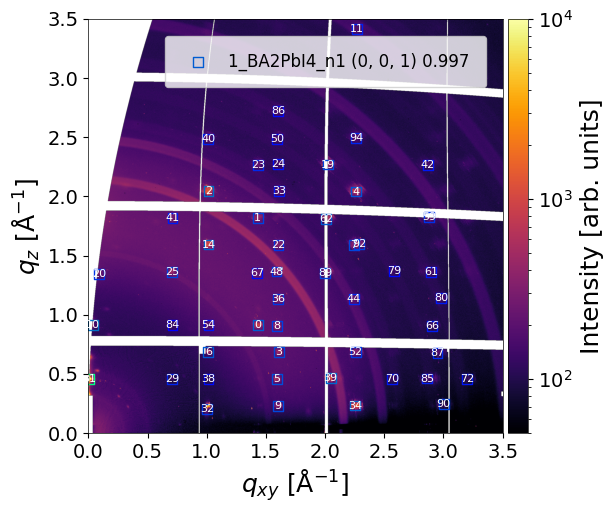

In [7]:
analysis.plot_analysis_results(
    matched_params=matched_params,
    entry='entry_0000',  # select entry
    frame_num=0,          # select frame
    clims=(50, 1e4),     # color map
)

**Note:** The datasets in the NeXus file are modified when peaks are added or deleted.

### Rings

Repeat the procedure for rings.
Visualize the matched rings:

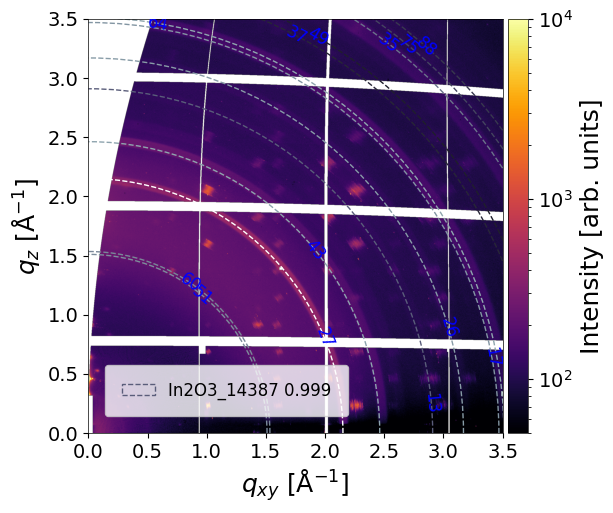

In [8]:
# Visualization settings for matched peaks (multiple structures in solution)
matched_params = {
    'solution': None,              # list of structures to display (None = all)
    'plot_segments': False,         # show matched peak positions
    'marker': ['s', 's', 's'],     # marker shapes for each structure
    'marker_size': [50, 50, 50],   # marker sizes for each structure
    'marker_facecolor': ["none", "none", "none"],  # marker fill colors
    'marker_edgecolor': ["winter", 'blue', 'green'], # marker edge colors per structure
    'plot_rings': True,            # draw matched rings
    'line_width': [1, 1, 1],       # line widths for each structure
    'line_style': ["--", "--", "--"], # line styles for each structure
    'line_color': ["bone", 'blue', 'bone'], # line colors per structure
    'plot_id': True,              # display peak IDs
    'text_color': 'black',         # color of ID labels
    'text_size': 12,                # font size of ID labels
    'legend': True,                # show legend for multiple structures
    'plot': True,                 # enable/disable plotting of matched peaks
}

# Plot analysis results with selected matched peak visualization
analysis.plot_analysis_results(
    matched_params=matched_params,
    entry='entry_0000',  # select entry
    frame_num=0,          # select frame
    clims=(50, 1e4),     # color map
)

Delete the peak #17

In [9]:
analysis.delete_peak(
    entry='entry_0000',
    frame_num=0,
    peak_id=17
)

Plot:

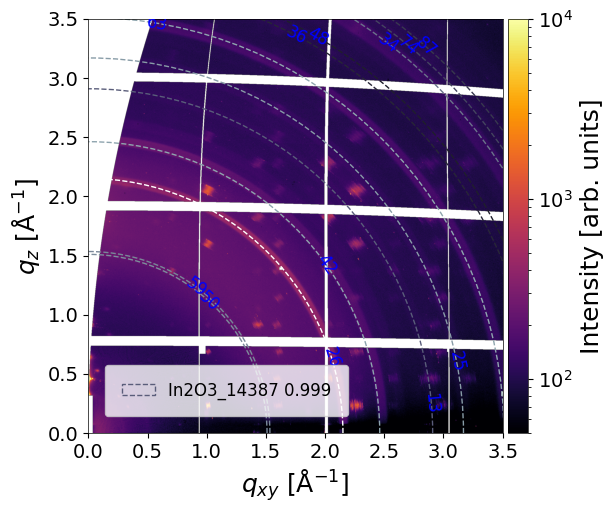

In [10]:
analysis.plot_analysis_results(
    matched_params=matched_params,
    entry='entry_0000',  # select entry
    frame_num=0,          # select frame
    clims=(50, 1e4),     # color map
)

Add a ring box:

In [11]:
analysis.add_peak(
    entry='entry_0000',
    frame_num=0,
    angle=45,       # angular center of the box (in deg). 45 for rings.
    angle_width=90, # angular width of the box (in deg). 90 for rings.
    radius=2.5,     # radial center of the box (Å⁻¹).
    radius_width=0.05, # radial width of the box (Å⁻¹)
)

INFO - Peak id#94 has been added


Run fitting and matching:

In [12]:
analysis.run_fitting()
analysis.run_matching(
    cif_prepr = r'../../example/prepr_cifs.pickle',
    peaks_type='segments')

analysis.run_matching(
    cif_prepr = r'../../example/prepr_cifs.pickle',
    peaks_type='rings')

INFO - Saved fitted peaks to file: ../../example/BA2PbI4.h5, entry: entry_0000, frame: 0
INFO - cif_prepr is already set. The previous cif_prepr is to be used
INFO - Saved matched peaks to file: ../../example/BA2PbI4.h5, entry: entry_0000, frame: 0
INFO - cif_prepr is already set. The previous cif_prepr is to be used
INFO - Saved matched peaks to file: ../../example/BA2PbI4.h5, entry: entry_0000, frame: 0


Plot:

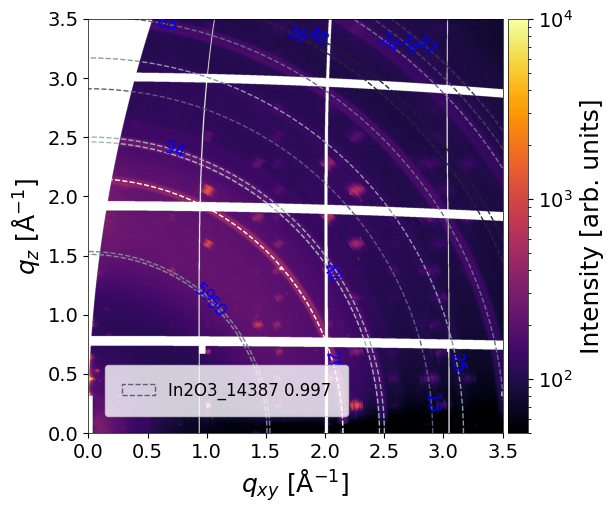

In [13]:
analysis.plot_analysis_results(
    matched_params=matched_params,
    entry='entry_0000',  # select entry
    frame_num=0,          # select frame
    clims=(50, 1e4),     # color map
)